# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 2. Линейная регрессия.


**Правила, <font color="red">прочитайте внимательно</font>:**

1. Общее

     * Выполненную работу **в формате `ipynb`** нужно отправить <будет объявлено в чате и в боте>. **Работы, присланные иным способом, не принимаются.** Дедлайны указаны в боте, они являются строгими. Переносы дедлайнов осуществляются по установленным <a href="https://thetahat.ru/deadlines"><b>правилам</b></a>.
     
     * Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><b>руководство по оформлению ДЗ</b></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.
     
     * Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
     
     * Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания (в т.ч. злоупотребление ИИ) всем участникам списывания дается штраф -3 скор-балла к итоговой оценке.**
     
     * Решение теоретических задач оформляйте в markdown-ячейках формате $\LaTeX$. При решении можно использовать ИИ-инструменты только для оформления написанного самостоятельно решения. Например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.
     
     * Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
     </br>

2. Правила заполнения ноутбука

     * Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.
     * Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены `<...>`.
     * Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках.
     * Условия <font color="red"><b>запрещается модифицировать</b></font>.
     * При нарушении данных правил работа может получить 0 баллов.
</br>

**Баллы за задание:**

* Задача 1 &mdash; 20 баллов;
* Задача 2 &mdash; 80 баллов;
* Задача 6 &mdash; 70 баллов;
* Задача 7 &mdash; 50 баллов.

In [191]:
# Bot check

# HW_ID: fpmi_ad2
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn import metrics


sns.set(style="whitegrid", palette="Set2")

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. [ссылка](https://chatgpt.com/share/699df6fe-7254-8009-8c80-df9a01a7b84e)
    - для латеха
    
**Задача 2**
1. [ссылка](https://chatgpt.com/share/69a0bf37-4a6c-8009-b6b6-a1ceab07a753)
    - для вопросов

**Задача 4**
1. [ссылка](https://chatgpt.com/share/69a1dde7-194c-8009-9aab-55ac2c97ad20)
    - для форматирования

*Привет!*

*Перед тобой увлекательная домашка по линейной регрессии и градиентным методам оптимизации. Надеемся, что тебе она понравится, ты точно найдешь в ней что-то интересное. В условии оставлены некоторые скрытые подсказки, будет хорошо, если ты сначала постараешься подумать самостоятельно, а затем раскроешь содержимое подсказки. Если у тебя будут вопросы по условию, можешь обратиться с ними в чат. Только очень желательно не делиться в чате фрагментами решения.*

*Успехов в решении!*

---
### Задача 1.

*Для начала простая задача для разминки.*

Рассмотрим модель одномерной линейной регрессии *без свободного параметра* $y(x) = \theta x$, где $x\in \mathbb{R}$ и $\theta \in \mathbb{R}$. Предполагаем, что данные получены по правилу
$$Y_i = \theta x_i + \varepsilon_i,$$
где $i \in \{1, ..., n\}$, числа $x_i \in \mathbb{R}$ неслучайны, а $\varepsilon_i$ &mdash; случайные ошибки.

**1.** Посчитайте оценку $\widehat{\theta}$ методом наименьших квадратов по явной формуле. В ответе во всех пунктах могут оставаться суммы $n$ слагаемых, но не должно быть операций с векторами или матрицами.

$$
(Y_i - \theta x_i)^2 = Y_i^2 - 2\theta x_i Y_i + \theta^2 x_i^2
$$

$$
\sum \varepsilon_i^2 = \sum (Y_i - \theta x_i)^2
= \sum Y_i^2 - 2\theta \sum x_i Y_i + \theta^2 \sum x_i^2
$$

Нужно минимизировать $\sum \varepsilon_i^2$ по $\theta$.

$$
\frac{d}{d\theta}\left(\sum \varepsilon_i^2\right)
= -2\sum x_i Y_i + 2\theta \sum x_i^2
$$

Приравниваем производную к нулю:

$$
-2\sum x_i Y_i + 2\theta \sum x_i^2 = 0
$$

Отсюда

$$
\hat{\theta} = \frac{\sum x_i Y_i}{\sum x_i^2}
$$

**2.** Выпишите формулы итераций градиентного спуска (GD) и стохастического градиентного спуска (SGD) для поиска $\widehat{\theta}$. Не забудьте указать, как в SGD математически определяется батч (набор объектов на каждой итерации).

Возьмём функцию потерь

$$
L(\theta) = \frac{1}{n}\sum (Y_i - \theta x_i)^2
$$

$$
\frac{d}{d\theta}(Y_i - \theta x_i)^2 = 2(Y_i-\theta x_i)(-x_i)
$$

Тогда

$$
\frac{dL}{d\theta} = \frac{1}{n}\sum\bigl(-2x_i(Y_i-\theta x_i)\bigr)
$$

Градиент

$$
\nabla L(\theta) = \frac{2}{n}\sum x_i(\theta x_i - Y_i)
$$

Градиентный спуск:

$$
\theta_{t+1} = \theta_t - \eta_t \cdot \frac{2}{n}\sum x_i(\theta_t x_i - Y_i)
$$

SGD:

Батч: случайно выбираем $B_t$ — $m$ объектов из всех (случайно, равномерно).

$$
L_{B_t}(\theta) = \frac{1}{|B_t|}\sum_{i \in B_t}(Y_i-\theta x_i)^2
$$

$$
\nabla L_{B_t}(\theta) = -\frac{2}{|B_t|}\sum_{i \in B_t}x_i(Y_i-\theta x_i)
$$

$$
\theta_{t+1} = \theta_t + \eta_t \cdot \frac{2}{|B_t|}\sum_{i \in B_t}x_i\bigl(Y_i-\theta_t x_i\bigr)
$$

**3.** Опишите, что произойдет, если для некоторого $i$ ошибка $\varepsilon_i$ будет очень большой.

Из-за того, что в MNK стоит квадрат, то она очень чувствительна к таким выбросам. Поэтому большой одиночный выброс может очень сильно влиять на ответ. Например, если есть какая-то например спортивная команда, в которой есть ветеран, (всем в районе 25 лет, ему 35), то предсказание среднего возраста может сильно сдвинуться от 25. Так же и с градиентным спуском и особенно с SGD, там мы будем слишком сильно подстраиваться под выброс.

ссылка на гпт https://chatgpt.com/share/699df6fe-7254-8009-8c80-df9a01a7b84e
для латеха

---
### Задача 2.

*Теперь давайте поупражняемся с простой линейной регрессией на реальных данных. Перед выполнением задачи ознакомьтесь с <a href="https://thetahat.ru/courses/ad/main/3/1_linreg">ноутбуком по линейной регрессии</a> с занятия.*


Скоро весна и лето &mdash; идеальное время года для путешествий и прогулок на велосипедах. В крупных городах обычно развиты сети проката велосипедов или самокатов, предоставляющие удобный сервис. Одной из важных задач таких компаний является прогнозирование количества арендованных велосипедов в зависимости от времени года и погодных условий.

Рассмотрим датасет <a target="_blank" href="https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset">Bike Sharing Dataset</a> от компании <a target="_blank" href="https://www.capitalbikeshare.com/">Capital Bikeshare</a>, располагающей автоматизированными пунктами проката велосипедов. В датасете по дням записаны календарная информация и погодные условия, а также число прокатов в этот день. Цель &mdash; предсказать количество арендованных велосипедов по остальным характеристикам.

<img src="https://thetahat.ru/files/ad/main/3/bike1.jpeg">

Будем работать только со следующими признаками:
* `season`: время года: 1 &mdash; зима, 2 &mdash; весна, 3 &mdash; лето, 4 &mdash; осень;
* `mnth`: месяц от 1 до 12;
* `holiday`: является ли текущий день праздничным;
* `weekday`: день недели от 0 до 6;
* `workingday`: является ли текущий день рабочим или выходным;
* `weathersit`: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень, туман);
* `temp`: температура в Цельсиях;
* `atemp`: температура по ощущениям в Цельсиях;
* `hum`: влажность воздуха;
* `windspeed`: скорость ветра;
* `cnt`: количество арендованных велосипедов за текущий день.

---

Скачайте данные, загрузите файл `day.csv` с помощью `pandas` и разделите на обучающую и тестовую части в соотношении 4:1. Далее всю аналитику необходимо проводить только на обучающей части данных.

In [129]:
day = pd.read_csv("bike+sharing+dataset/day.csv")
day.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [130]:
train, test = train_test_split(day, test_size=0.2, random_state=1086)
print(len(train), len(test))

584 147


#### 1. Визуальный анализ

*Помочь в выполнении может ноутбук по линейной регрессии с занятия 2 и ноутбук по EDA с занятия 1.*

Посмотрите по графикам, как *целевой признак зависит от остальных* и поймите характер этой зависимости. Старайтесь строить информативные графики, а из финального решения убирать те, которые не пригодились.

Какие признаки категориальные, а какие &mdash; вещественные? Учтите это при построении информативных графиков.

<br/><details>
<summary> ➡️ Кликни для показа подсказки </summary>
Среди признаков есть такие, значения которых как-то упорядочены, и их относительно небольшое количество. Чтобы понять, являются ли они категориальными, попробуйте понять, как с их значениями будут работать линейные модели. Иначе говоря, допустимо ли с точки зрения природы данных выполнять арифметические операции между *любыми* значениями этого признака, согласуется ли это со смыслом, который несет в себе данный признак?
</details>

In [131]:
features = [col for col in day.columns if col not in ["cnt", "instant", "dteday", "yr", "casual", "registered"]] # наши признаки
print(features)
target = "cnt"


['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']


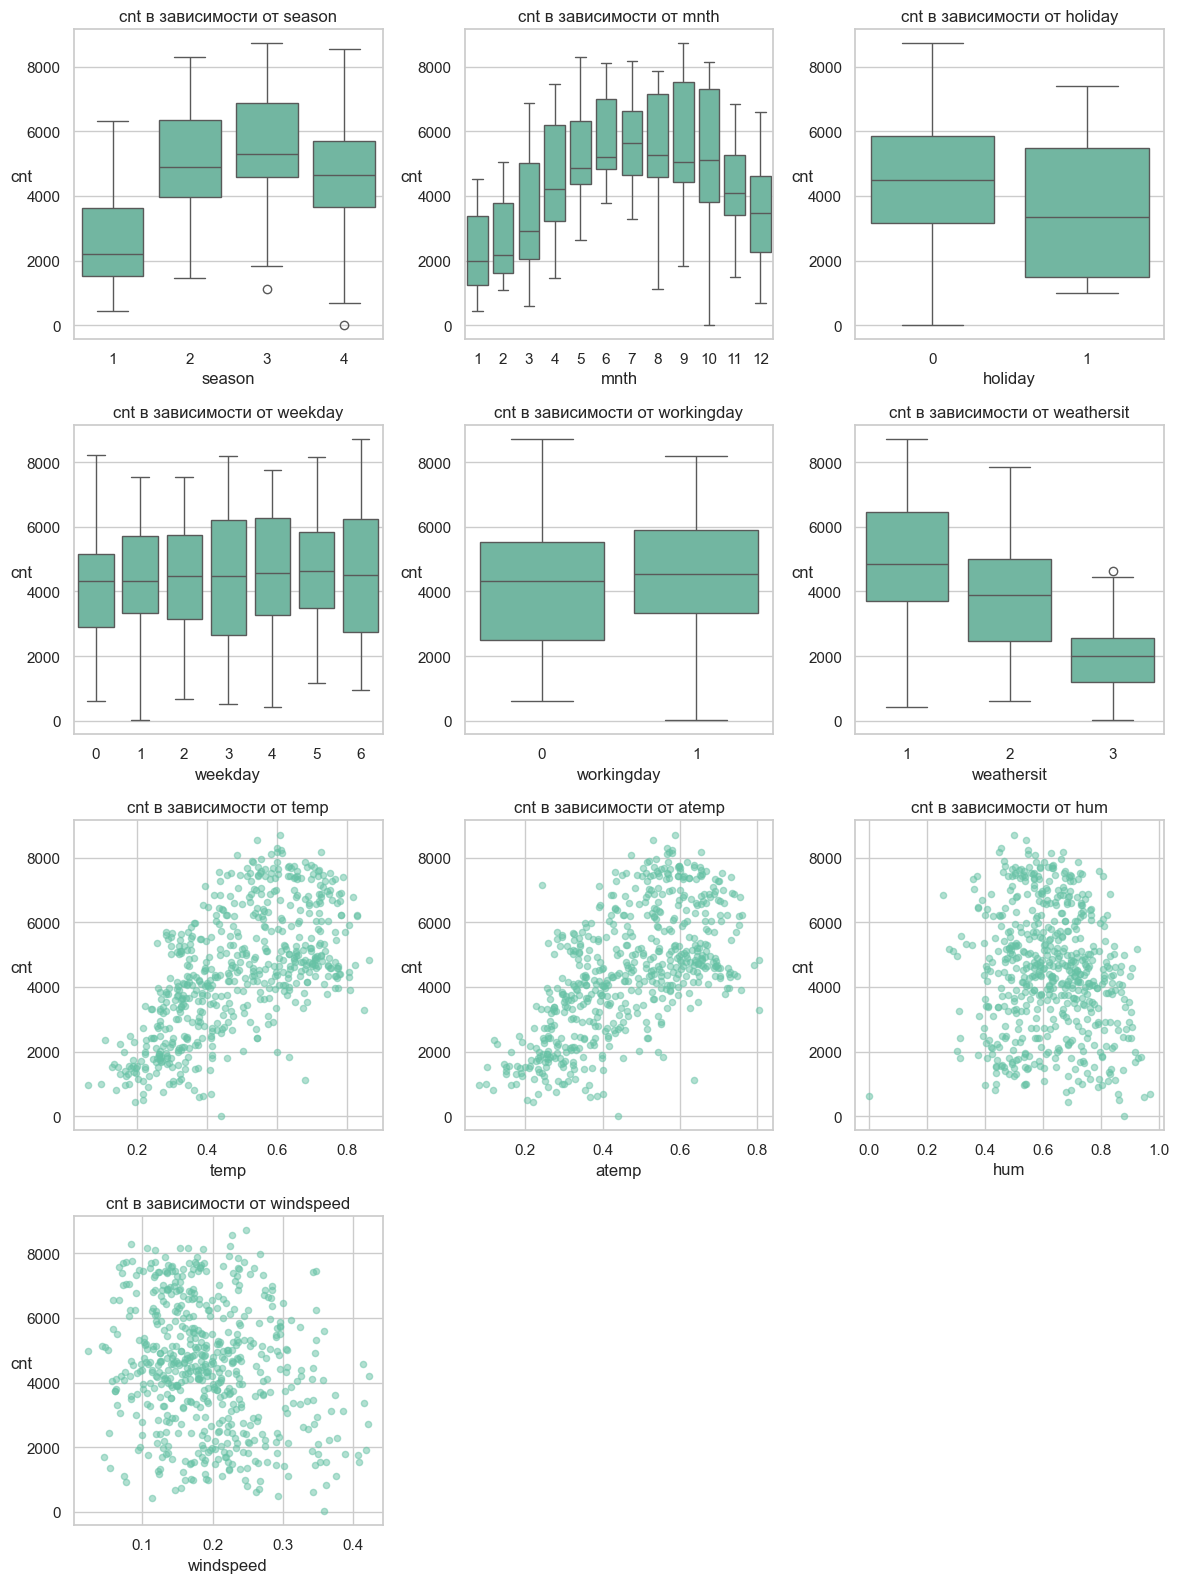

In [132]:
n = len(features)
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
axes = axes.flatten()
# Рисуем графики, скаттеры для численных признаков, боксплоты для категориальных, все это в сабплоте

i = -1
for col in features:
    i += 1
    ax = axes[i]
    if col in ["temp", "atemp", "hum", "windspeed"]:
        ax.scatter(train[col], train["cnt"], alpha=0.5, s=20)
        ax.set_xlabel(col)
        ax.set_ylabel("cnt", rotation=0)
        ax.set_title(f"cnt в зависимости от {col}")
    else:
        sns.boxplot(x=col, y="cnt", data=train, ax=ax)
        ax.set_xlabel(col)
        ax.set_ylabel("cnt", rotation=0)
        ax.set_title(f"cnt в зависимости от {col}")

axes[10].set_visible(False)
axes[11].set_visible(False)

plt.tight_layout()
plt.show()


Сделайте выводы по графикам. В частности, ответьте на следующие вопросы.
* Есть ли в данных явные выбросы, то есть точки, далеко находящиеся от основной массы точек?
* Стоит ли рассматривать какие-либо нелинейные функции от признаков? Не стоит придумывать сложные функции, достаточно рассмотреть $x^2, \log x, I\{x > c\}$.
* <font color="red"><b>Не стоит сильно закапываться в анализ графиков и подбор функций.</b></font> Время у всех ограничено, а есть более интересные задачи. Достаточно сделать 2-4 содержательных вывода и рассмотреть возможность добавления небольшого количества признаков.



**Выводы по графикам:**
Выбросы есть, например по сезону или по дню работы, или по влажности.
Проглядываются линейные зависимости от temp и atemp (причем схожие), что довольно логично. Но возможно они квадратичные, поэтому можно добавить квадраты. Сезоны по сути дублируют месяцы, поэтому можно удалить сезоны, чтобы не произошло переобучения. Также, как будто, нет явной зависимости от влажности и скорости ветра, поэтому их тоже можно удалить. Остальные лучше конвертировать в бинарные, потому что зависимость вроде бы есть, но она не видна сразу, либо категорий слишком мало.

#### 2. Подготовка данных

Опишите по шагам процедуру предобработки данных, которая будет включать работу с выбросами, преобразования вещественных и категориальных признаков, возможно, создание каких-либо новых признаков (посмотрите <a href="https://thetahat.ru/courses/ad/main/3/1_linreg">пример</a> с занятия). То, как именно выполнять подготовку данных, является целым исскуством. Здесь нет "правильного" подхода, здесь есть метрика качества на тестовом множестве, которая в последствии оценит качество вашей модели.

*Обратите внимание, от того, насколько качественно вы проведете визуальный анализ и подготовку данных, будет зависеть качество ваших моделей на следующих шагах.*

**Процедура предобработки данных:**

**a).** Сначала удалим season, windspeed и hum.

**b).** Потом закодируем категории в бинарные через OneHotEncoder. Первый класс убираем, так как он выводится через остальные.

**c).** Добавляем квадраты всех оставшихся численных признаков.

**d).** Убираем максимум и минимум из каждого класса категории, чтобы убрать выбросы.

Реализуйте данную процедуру.

In [133]:
cols_drop = ["season", "hum", "windspeed"]

train = train.drop(columns=cols_drop, errors="ignore")
test = test.drop(columns=cols_drop, errors="ignore")

categories = ["mnth", "holiday", "weekday", "workingday", "weathersit"] # категориальные признаки
nums = ["temp", "atemp"] # численные признаки

encoder = OneHotEncoder(drop="first", sparse_output=False)
train_cat = encoder.fit_transform(train[categories])  # кодируем
test_cat = encoder.transform(test[categories])
train_cat


array([[0., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]], shape=(584, 21))

In [134]:
cat_features = encoder.get_feature_names_out(categories) # получаем названия новых признаков
train_cat_df = pd.DataFrame(train_cat, columns=cat_features)
test_cat_df  = pd.DataFrame(test_cat,  columns=cat_features)

train_cat_df.head()

,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,...,holiday_1,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,weathersit_2,weathersit_3
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [135]:
train_num = train[nums].copy() # численные признаки
test_num = test[nums].copy()

for col in nums:
    train_num[f"square_{col}"] = train_num[col] ** 2 # добавляем квадраты численных признаков
    test_num[f"square_{col}"] = test_num[col] ** 2
train_num_df = pd.DataFrame(train_num, index=train.index)
test_num_df = pd.DataFrame(test_num, index=test.index)
train_num_df = train_num_df.reset_index(drop=True)
test_num_df = test_num_df.reset_index(drop=True)

train_num_df.head()


,temp,atemp,square_temp,square_atemp
0,0.165000,0.162254,0.027225,0.026326
1,0.220833,0.198246,0.048767,0.039301
2,0.216522,0.250322,0.046882,0.062661
3,0.303333,0.284075,0.092011,0.080699
4,0.550833,0.529675,0.303417,0.280556


In [136]:
X_train = pd.concat([train_cat_df, train_num_df], axis=1) # объединяем
X_test = pd.concat([test_cat_df, test_num_df], axis=1)
y_train = train[target]
y_test  = test[target]
X_train.head()




,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,...,weekday_4,weekday_5,weekday_6,workingday_1,weathersit_2,weathersit_3,temp,atemp,square_temp,square_atemp
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.165000,0.162254,0.027225,0.026326
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.220833,0.198246,0.048767,0.039301
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.216522,0.250322,0.046882,0.062661
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.303333,0.284075,0.092011,0.080699
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.550833,0.529675,0.303417,0.280556


In [137]:
cat_cols = list(cat_features)

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

mask = pd.Series(True, index=X_train.index)

for col in cat_cols:
    idx = X_train.index[X_train[col] == 1]
    if len(idx) <= 10:
        continue

    y_group = y_train.loc[idx]
    mask.loc[y_group.idxmin()] = False
    mask.loc[y_group.idxmax()] = False

X_train_2 = X_train.loc[mask].copy()
y_train_2 = y_train.loc[mask].copy()

print(len(X_train_2), len(y_train_2))
X_train_2.head()
# удаляем по 1 точке из каждого класса каждой категории сверху и снизу (убираем выбросы)


549 549


,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,...,weekday_4,weekday_5,weekday_6,workingday_1,weathersit_2,weathersit_3,temp,atemp,square_temp,square_atemp
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.220833,0.198246,0.048767,0.039301
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.216522,0.250322,0.046882,0.062661
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.550833,0.529675,0.303417,0.280556
5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.403333,0.390767,0.162678,0.152699
6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.222500,0.227913,0.049506,0.051944


#### 3. Обучение модели и ее анализ


*Помочь в выполнении может ноутбук по линейной регрессии с занятия 2.*

Обучите линейную регрессию из `sklearn` на полученных данных и посмотрите на полученные оценки коэффициентов (в т.ч. свободный коэффициент).

In [138]:
model = LinearRegression()
model.fit(X_train_2, y_train_2)

print("intercept =", model.intercept_)
coef = pd.Series(model.coef_, index=X_train_2.columns).sort_values(key=lambda s: s.abs(), ascending=False)
coef



intercept = -1114.7965909241102


temp            24144.575641
square_temp    -20992.911775
square_atemp     7200.207256
atemp           -6241.527805
weathersit_3    -2805.393369
mnth_7           1189.131230
mnth_10          1163.407757
mnth_9           1105.429644
mnth_8           1083.468471
mnth_6           1061.880168
weathersit_2     -740.514958
mnth_5            717.668591
mnth_11           647.200145
weekday_6         429.172155
workingday_1      424.962728
holiday_1        -311.806166
mnth_4            284.159800
mnth_2           -279.753830
mnth_12           197.899448
weekday_4         165.252756
weekday_2        -124.442713
weekday_3         102.731712
weekday_1         -77.978826
weekday_5          47.593632
mnth_3            -43.798459
dtype: float64

Посчитайте ошибку предсказания на тестовой выборке по метрикам RMSE, MAE, MAPE.  Подробнее можно почитать в <a href="https://thetahat.ru/courses/ad/main/3/1_linreg">ноутбуке</a> с занятия.

*Замечание.* Если в тестовой части тоже есть "большие" выбросы, их стоит убрать. Наша модель не должна пытаться их предсказать (например, сбои в работе сервиса), но в то же время выбросы вносят существенный вклад в значение метрики. Особенно стоит обратить на это внимание в случае высоких значений метрик, например, значения MAPE $\approx$ 100% &mdash; точно плохо.

In [139]:
y_test_pred = model.predict(X_test)
rmse1 = metrics.mean_squared_error(y_test, y_test_pred) ** 0.5
print(f"RMSE: {rmse1:.2f}")
mae1 = metrics.mean_absolute_error(y_test, y_test_pred)
print(f"MAE: {mae1:.2f}")
mape1 = 100 * metrics.mean_absolute_percentage_error(y_test, y_test_pred)
print(f"MAPE: {mape1:.2f}%")

RMSE: 1372.94
MAE: 1171.74
MAPE: 30.37%


In [140]:
cat_cols = list(cat_features)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

mask = pd.Series(True, index=X_test.index)

for col in cat_cols:
    idx = X_test.index[X_test[col] == 1]
    if len(idx) <= 10:
        continue

    y_group = y_test.loc[idx]
    mask.loc[y_group.idxmin()] = False
    mask.loc[y_group.idxmax()] = False

X_test_2 = X_test.loc[mask].copy()
y_test_2 = y_test.loc[mask].copy()
# удаляем по 1 точке из каждого класса каждой категории сверху и снизу (убираем выбросы)

In [141]:
y_test_pred_2 = model.predict(X_test_2)

rmse2 = np.sqrt(metrics.mean_squared_error(y_test_2, y_test_pred_2))
mae2  = metrics.mean_absolute_error(y_test_2, y_test_pred_2)
mape2 = 100 * metrics.mean_absolute_percentage_error(y_test_2, y_test_pred_2)
print(f"RMSE: {rmse2:.2f}")
print(f"MAE: {mae2:.2f}")
print(f"MAPE: {mape2:.2f}%")

RMSE: 1287.51
MAE: 1110.05
MAPE: 27.31%


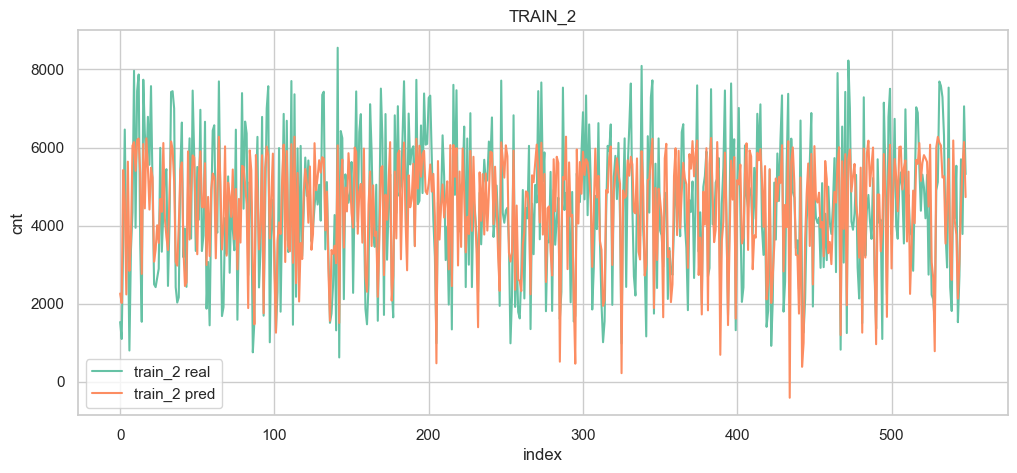

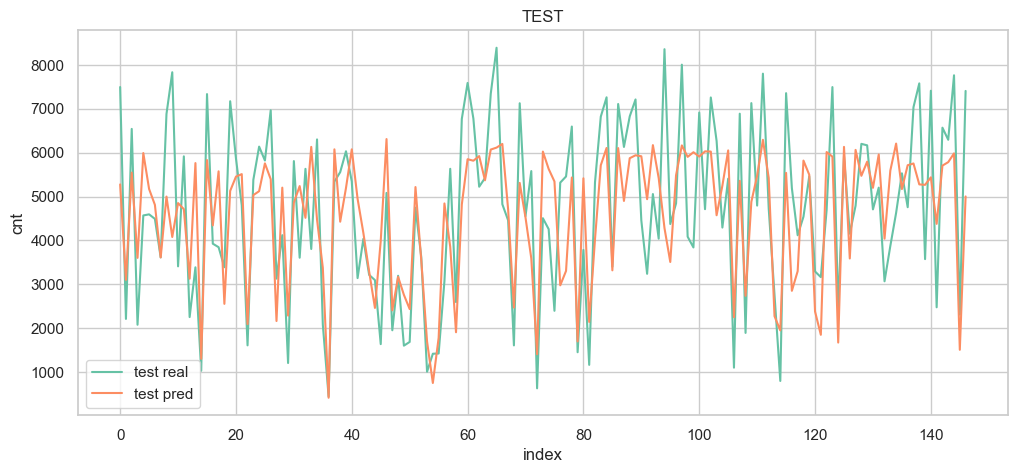

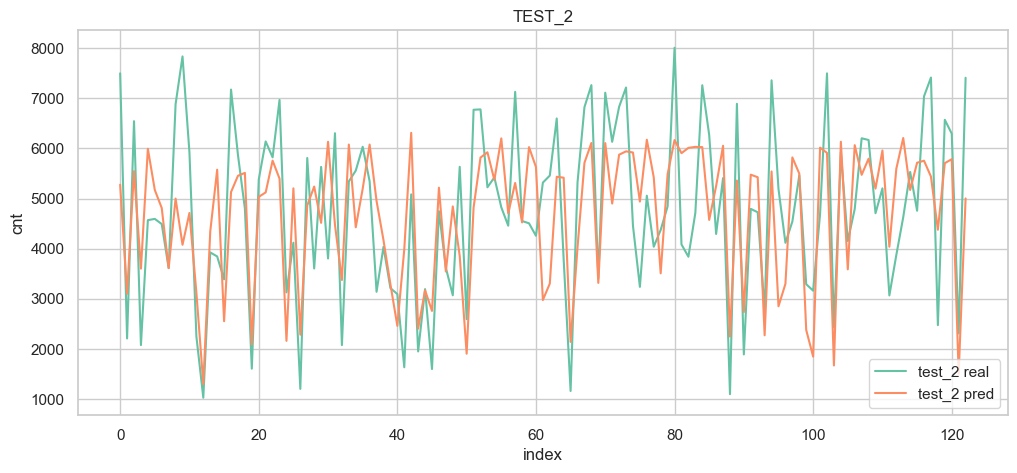

In [142]:
# TRAIN_2
plt.figure(figsize=(12, 5))
plt.plot(y_train_2.values, label="train_2 real")
plt.plot(model.predict(X_train_2), label="train_2 pred")
plt.title("TRAIN_2")
plt.xlabel("index"); plt.ylabel("cnt")
plt.grid(True); plt.legend()
plt.show()

# TEST
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="test real")
plt.plot(model.predict(X_test), label="test pred")
plt.title("TEST")
plt.xlabel("index"); plt.ylabel("cnt")
plt.grid(True); plt.legend()
plt.show()

# TEST_2 (после чистки)
plt.figure(figsize=(12, 5))
plt.plot(y_test_2.values, label="test_2 real")
plt.plot(model.predict(X_test_2), label="test_2 pred")
plt.title("TEST_2")
plt.xlabel("index"); plt.ylabel("cnt")
plt.grid(True); plt.legend()
plt.show()

Попробуйте посчитать оценку коэффициентов с помощью точной аналитической формулы, полученной на занятии (самостоятельно реализуйте ее). Не забудьте про константный признак.

In [143]:
# analytic coef
X = X_train_2.to_numpy()
y = y_train_2.to_numpy()

X1 = np.hstack([np.ones((X.shape[0], 1)), X])
# добавили intercept
A = X1.T @ X1
b = X1.T @ y

theta = np.linalg.pinv(A) @ b

intercept_new = theta[0]
coef_new = pd.Series(theta[1:], index=X_train_2.columns)

# old coef
coef_old = coef.copy()
coef_new_sorted_like_old = coef_new.reindex(coef_old.index)

# сравнение
cmp = pd.DataFrame({
    "coef_old": coef_old,
    "coef_new": coef_new_sorted_like_old
})
cmp["diff"] = cmp["coef_old"] - cmp["coef_new"]

cmp

,coef_old,coef_new,diff
temp,24144.575641,24144.575641,3.467867e-07
square_temp,-20992.911775,-20992.911774,-3.439854e-07
square_atemp,7200.207256,7200.207256,3.769919e-07
atemp,-6241.527805,-6241.527805,-3.474479e-07
weathersit_3,-2805.393369,-2805.393369,-7.271410e-10
mnth_7,1189.131230,1189.131230,5.666152e-10
mnth_10,1163.407757,1163.407757,-1.737590e-09
mnth_9,1105.429644,1105.429644,-1.673243e-09
mnth_8,1083.468471,1083.468471,-7.780727e-10
mnth_6,1061.880168,1061.880168,-1.007948e-09


Посчитайте также определить матрицы $X^T X$

In [144]:
A = X1.T @ X1
detA = np.linalg.det(A)
print(detA)

3.179445948014934e+18


In [145]:
X_train_2[["temp", "atemp"]].corr()

,temp,atemp
temp,1.000000,0.989751
atemp,0.989751,1.000000


Наблюдается ли какая-то проблема?

<br/><details>
<summary> ➡️ Кликни для показа подсказки </summary>
Подумайте о зависимостях между признаками. Есть ли среди них сильно зависимые признаки? 
    
Причем, возможно, вы уже могли решить эту проблему на предыдущих этапах. Тогда все хорошо :)
</details>

Нет вроде. Но на всякий случай я убрал дальше temp и square_temp, потому что они очень коррелируют.

Если выше была проблема, исправьте ее проблему, посчитайте оценки коэффициентов, а также ошибку предсказания.

In [146]:

drop_cols = ["temp", "square_temp"]

X_train_2 = X_train_2.drop(columns=drop_cols, errors="ignore")
X_test    = X_test.drop(columns=drop_cols, errors="ignore")
X_test_2  = X_test_2.drop(columns=drop_cols, errors="ignore")

model = LinearRegression()
model.fit(X_train_2, y_train_2)
coef = pd.Series(model.coef_, index=X_train_2.columns).sort_values(
    key=lambda s: s.abs(), ascending=False
)

print("intercept =", model.intercept_)
print(coef)

A = X1.T @ X1
detA = np.linalg.det(A)
print(detA)



intercept = -1227.3675753455327
atemp           18886.382064
square_atemp   -16010.868239
weathersit_3    -2745.987837
mnth_9           1340.829254
mnth_7           1338.325895
mnth_10          1334.232957
mnth_8           1330.835608
mnth_6           1275.411758
mnth_5            956.384604
weathersit_2     -745.373715
mnth_11           728.068567
mnth_4            471.736658
workingday_1      421.174377
weekday_6         414.106582
holiday_1        -313.028722
mnth_2           -265.865568
mnth_12           226.967848
weekday_4         173.968329
weekday_2        -126.025694
weekday_3         103.148017
weekday_1         -97.035106
mnth_3             92.047502
weekday_5          54.090108
dtype: float64
3.179445948014934e+18


In [147]:
print(coef_new_sorted_like_old)

temp            24144.575641
square_temp    -20992.911774
square_atemp     7200.207256
atemp           -6241.527805
weathersit_3    -2805.393369
mnth_7           1189.131230
mnth_10          1163.407757
mnth_9           1105.429644
mnth_8           1083.468471
mnth_6           1061.880168
weathersit_2     -740.514958
mnth_5            717.668591
mnth_11           647.200145
weekday_6         429.172155
workingday_1      424.962728
holiday_1        -311.806166
mnth_4            284.159800
mnth_2           -279.753830
mnth_12           197.899448
weekday_4         165.252756
weekday_2        -124.442713
weekday_3         102.731712
weekday_1         -77.978826
weekday_5          47.593632
mnth_3            -43.798459
dtype: float64


In [148]:
y_test_pred_2 = model.predict(X_test_2)

rmse2 = np.sqrt(metrics.mean_squared_error(y_test_2, y_test_pred_2))
mae2  = metrics.mean_absolute_error(y_test_2, y_test_pred_2)
mape2 = 100 * metrics.mean_absolute_percentage_error(y_test_2, y_test_pred_2)
print(f"RMSE: {rmse2:.2f}")
print(f"MAE: {mae2:.2f}")
print(f"MAPE: {mape2:.2f}%")

RMSE: 1262.89
MAE: 1087.10
MAPE: 26.72%


Сделайте выводы.

**Выводы:**
Самый сильный параметр - atemp (или temp). Самый слабый - день недели. Выбросы очень сильно влияют, поэтому их очень важно контролировать. Также лучше убирать сильно зависимые признаки. Общая идея понятна: сначала посмотреть на графики, определить зависимости, выбрать признаки для регресии, ковертировать категории, убрать линейно зависимые. И после этого можно обучать.


ссылка на гпт https://chatgpt.com/share/69a0bf37-4a6c-8009-b6b6-a1ceab07a753
для вопросов

*Замечание.* Не расстраивайтесь, если у вас получится не очень хорошее качество, это нормально. Вы провели только небольшую предобработку данных и обучили *простую* модель. Более сложные методы обработки данных и обучения ждут вас впереди. Главное &mdash; с чего-то начать!

<img src="https://thetahat.ru/files/ad/main/3/bike2.png">

*Ты молодец, уже две задачи позади!* 🎉 

*Впереди еще лве задачи, но не пугайся, они тебе понравятся! А пока сделай перерыв, возьми чай или кофе* 😊

---
### Задача 3.

*Теперь давайте углубимся в теорию градиентных методов оптимизации. Эти подходы будут часто встречаться, поэтому важно освоить их применение. Для этого применим градиентные методы в другом методе обучения линейной регрессии.*

В этой задаче вам предлагается реализовать регрессию Хьюбера, а также применить ее к данным с выбросами. Для начала реализуйте класс по шаблону снизу. Обратите внимание, что класс `HuberRegression` &mdash; наследник класса `BaseEstimator`, это с легкостью позволит использовать наш класс в различных пайплайнах библиотеки `sklearn`.

**1.** Рассмотрим линейную регрессию $y(x) = x^T \theta$, причем для оценки $\theta$ будем рассматривать функцию потерь Хьюбера
$$R(x) = \frac{x^2}{2} I\{|x| \leqslant c\} + c\left(|x| - \frac{c}{2}\right)I\{|x| > c\}.$$

Тем самым задача оптимизации имеет вид
$$\sum_{i=1}^n R(Y_i - x_i^T \theta) \longrightarrow \min_{\theta \in \mathbb{R}^d}.$$

Нарисуйте график $R(x)$

In [156]:
def R(x, c=1.0):
    x = np.asarray(x)
    mask = np.abs(x) <= c
    return np.where(mask, 0.5 * x**2, c * (np.abs(x) - 0.5 * c))

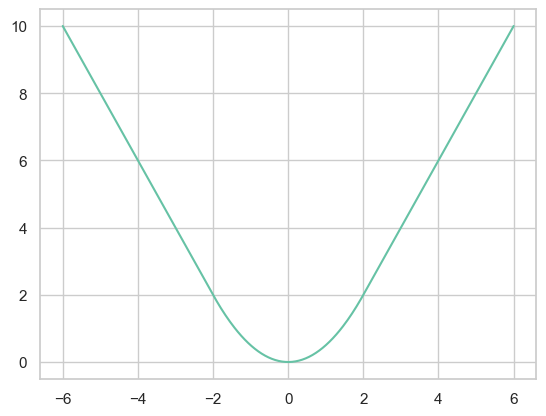

In [157]:
x = np.linspace(-6, 6, 400)
c = 2.0

y = R(x, c)

mask = np.abs(x) <= c

plt.figure()
plt.plot(x, y)
plt.show()

В чем польза выбора такой функции потерь?

<br/><details>
<summary> ➡️ Кликни для показа подсказки </summary>
    
1. Подумайте, что происходит в случае больших отклонений предсказаний от истины? Что это за точки?
    
2. Обратите внимание на поведение $R(x)$ в точке $x=c$.
</details>

Соединяет плюсы как раз двух функций из 4-го задания. Выбросы не так сильно влияют, потому что на них функция линейна. А при x < c зависимость квадратичная, то есть более простая быстрая и гладкая оптимизация. При этом в точке с все гладенько, непрерывная производная.

Выпишите математические формулы градиентного спуска (GD) и стохастического градиентного спуска (SGD).

$$
r_i(\theta)=Y_i-x_i^T\theta,
\qquad
\psi_c(r)=
\begin{cases}
r,& |r|\le c,\\
c\,\mathrm{sign}(r),& |r|>c.
\end{cases}
$$

**GD:**
$$
\theta_{t+1}
=\theta_t+\eta_t\sum_{i=1}^n \psi_c\!\bigl(Y_i-x_i^T\theta_t\bigr)\,x_i.
$$

**SGD:**
$$
\theta_{t+1}
=\theta_t+\eta_t\sum_{i\in B_t}\psi_c\!\bigl(Y_i-x_i^T\theta_t\bigr)\,x_i.
$$

*Хочется что-то закодить? Поехали!*

**2.** Реализуем теперь класс. **При реализации класса запрещено пользоваться ИИ-инструментами.**

In [184]:
class HuberRegression(BaseEstimator):
    """Класс, реализующий линейную регрессию с функцией потерь Хьюбера."""

    def __init__(self, c: float = 1.0, fit_intercept: bool = True, max_iter: int = 1000) -> None:
        """Инициализирует модель.

        Параметры: c (float): Константа из функции потерь Хьюбера.
        fit_intercept (bool): Добавлять ли константный признак. max_iter
        (int): Максимальное число итераций оптимизации.
        """
        self.c = c
        self.fit_intercept = fit_intercept
        self.max_iter = max_iter

    def fit(self, X: np.ndarray, y: np.ndarray) -> "HuberRegression":
        """Обучает модель.

        Параметры:
        X (np.ndarray): Матрица признаков.
        y (np.ndarray): Вектор целевой переменной.

        Возвращает:
        HuberRegression: Обученная модель.
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        if X.shape[0] != y.shape[0]:
            raise ValueError("Количество строк в X и y должно совпадать")
        
        n_samples = X.shape[0]
        step = 0.01 # - шаг спуска
        stop = 0.01 # - критерий остановки
        if self.fit_intercept:
            ones = np.ones((n_samples, 1))
            X = np.hstack([ones, X])
        
        theta = np.zeros(X.shape[1], dtype=float)

        for it in range(self.max_iter):
            y_pred = X @ theta
            error = y - y_pred
            mask = np.abs(error) <= self.c
            psi = np.where(mask, error, self.c * np.sign(error))

            grad = -(X.T @ psi)
            theta_new = theta - step * grad
            if np.linalg.norm(theta_new - theta) < stop:
                theta = theta_new
                self.n_iter_ = it + 1
                break
            theta = theta_new
            self.n_iter_ = it + 1

        if self.fit_intercept:
            self.intercept_ = float(theta[0])
            self.coef_ = theta[1:].copy()
        else:
            self.intercept_ = 0.0
            self.coef_ = theta.copy()

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Делает предсказание на новых данных.

        Параметры: X (np.ndarray): Матрица признаков.

        Возвращает: np.ndarray: Вектор предсказанных значений.
        """
        X = np.asarray(X, dtype=float)
        if X.shape[1] != self.coef_.shape[0]:
            raise ValueError("Число признаков в X не соответствует числу коэффициентов модели")
        pred = X @ self.coef_ + self.intercept_
        return pred

**3.** Загрузите данные из файлов `train.csv`, `test.csv`. Не забудьте, что всю аналитику, а также процесс обучения и подбор гиперпараметров необходимо выполнять на обучающей выборке.

In [185]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
test.head()

,feature_1,feature_2,feature_3,target
0,-0.704700,2.256723,0.943261,245.538820
1,0.820248,-1.054628,0.463130,108.929550
2,-0.888971,-1.681218,0.242118,-13.787683
3,-1.226196,-0.375147,0.183339,37.905525
4,-1.029935,0.220508,-0.349943,45.853628


Посмотрите на зависимость целевой переменной от каждого признака.

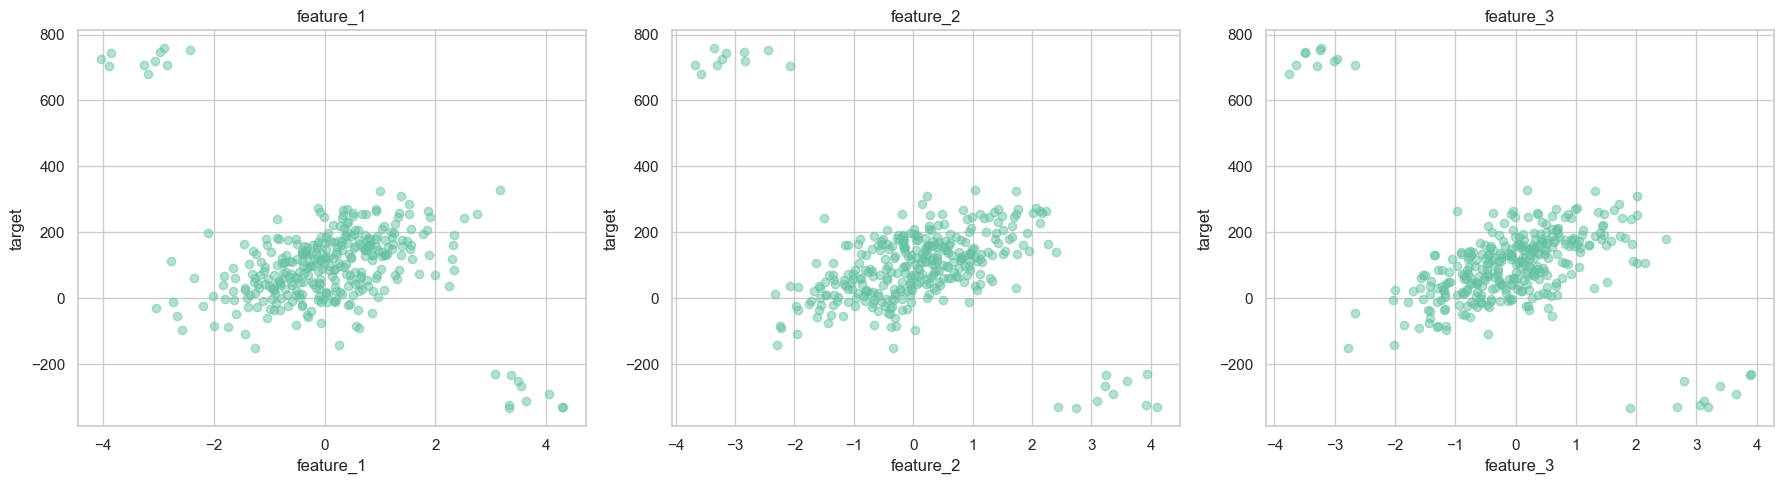

In [186]:
features = ["feature_1", "feature_2", "feature_3"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]
    ax.scatter(train[feature], train["target"], alpha = 0.5)
    ax.set_xlabel(feature)
    ax.set_ylabel("target")
    ax.set_title(feature)
plt.tight_layout()
plt.show()

Что можно сказать о наличии возможных выбросов? Какое влияние они могут оказать? 

Есть явно выбивающиеся точки, но не факт, что это выбросы, возможно они влияют на общую зависимость. Например, что в выборке обязательно есть представители с большим и маленьким таргетом, причем явно зависящие от фичи.

**4.** Обучите простую линейную регрессию и посчитайте качество на тестовой выборке по метрике [MSE](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html#sklearn.metrics.mean_squared_error).

In [187]:
X_train = train[features]
y_train = train["target"]

model_3 = LinearRegression()
model_3.fit(X_train, y_train)
mse = np.sqrt(metrics.mean_squared_error(test["target"], model_3.predict(test[features])))
print(mse)


130.48297440711926


Что можно сказать о качестве нашей модели?

Не очень точно

**5.** Теперь обучите линейную регресcию Хьюбера и посчитайте качество на тестовой части по метрикe MSE.

In [188]:
huber_model = HuberRegression()
huber_model.fit(X_train, y_train)
huber_mse = np.sqrt(metrics.mean_squared_error(test["target"], huber_model.predict(test[features])))
print(huber_mse)





4.779230262949899


Что изменилось?

Точность увеличилась в разы

**6.** Для обучающей выборки постройте два графика (по графику на каждую модель), на которых изобразите зависимость истинного и предсказанного значения таргета от каждого признака.

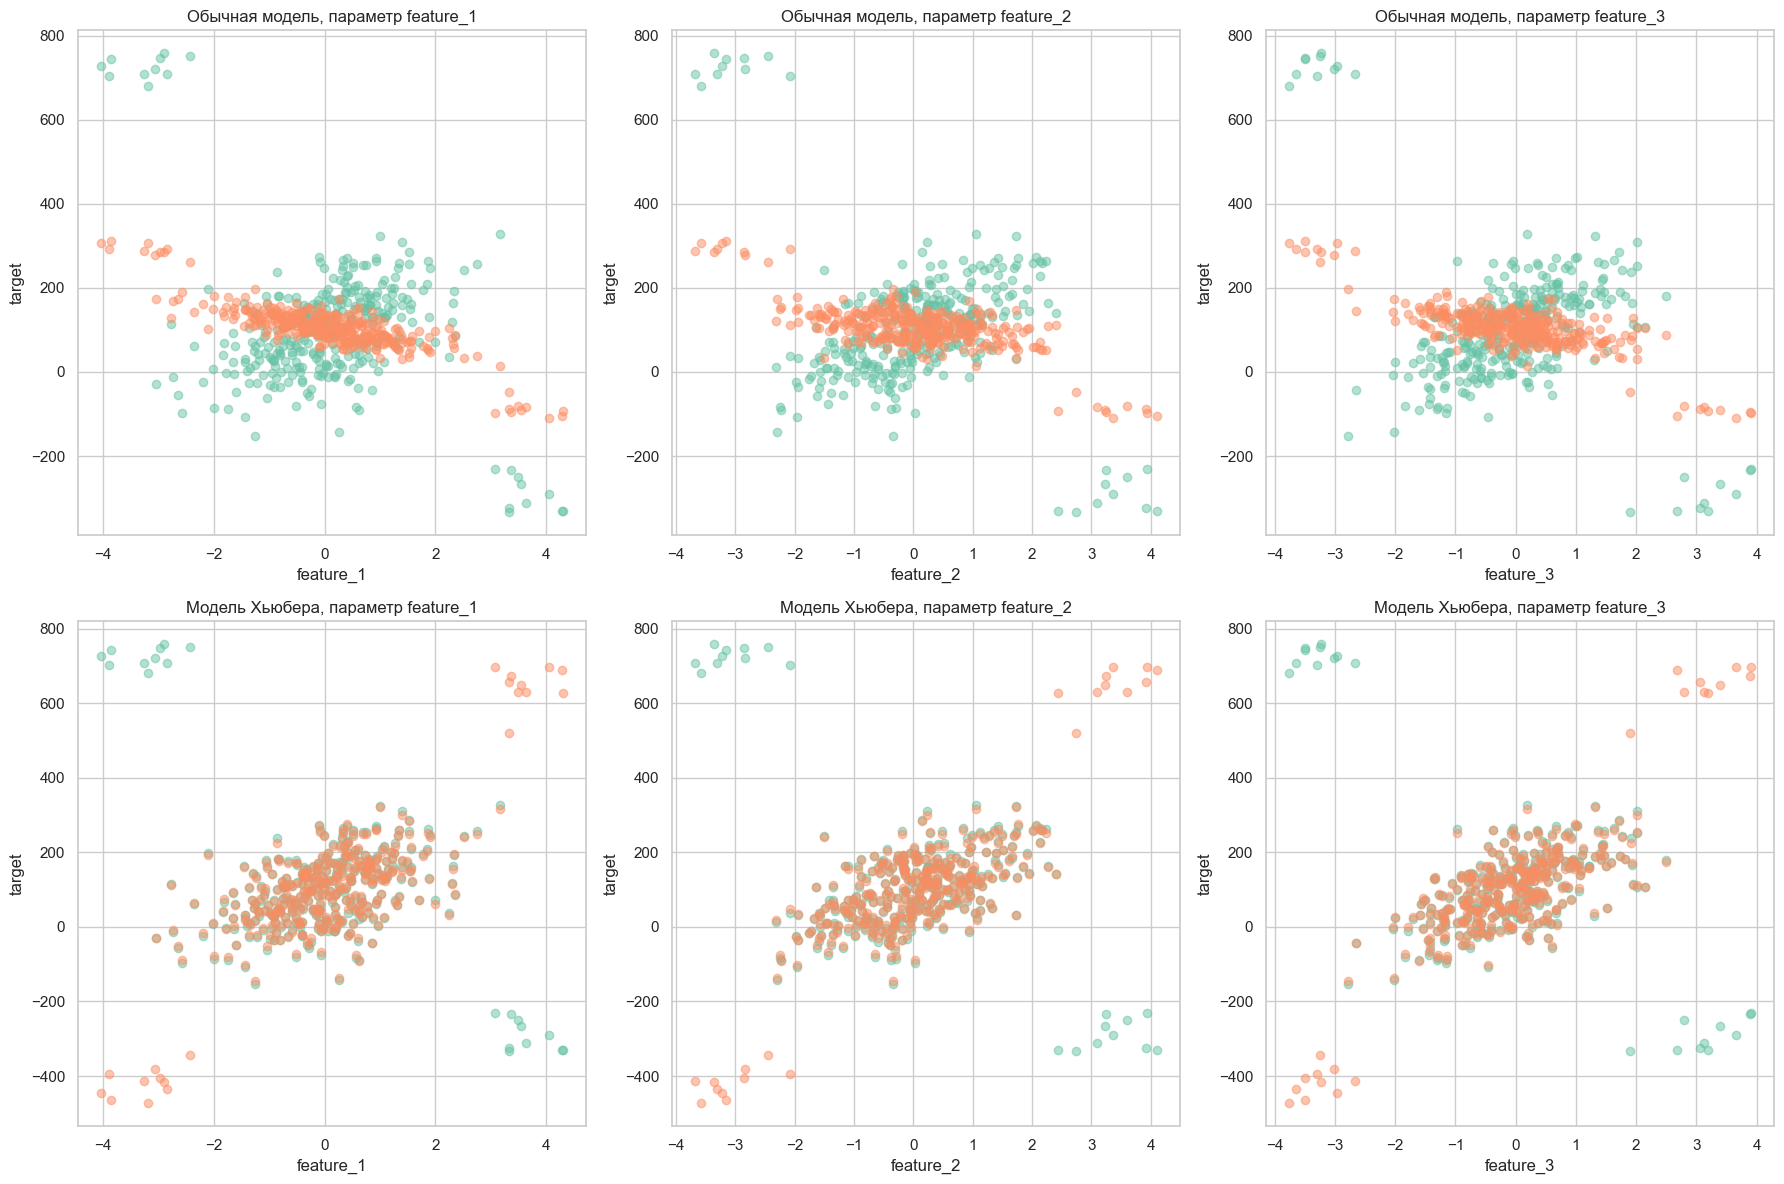

In [189]:
features = ["feature_1", "feature_2", "feature_3"]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]
    ax.scatter(train[feature], train["target"], alpha = 0.5)
    ax.scatter(train[feature], model_3.predict(X_train), alpha = 0.5)
    ax.set_xlabel(feature)
    ax.set_ylabel("target")
    ax.set_title(f"Обычная модель, параметр {feature}")
for i, feature in enumerate(features):
    ax = axes[i+3]
    ax.scatter(train[feature], train["target"], alpha = 0.5)
    ax.scatter(train[feature], huber_model.predict(X_train), alpha = 0.5)
    ax.set_xlabel(feature)
    ax.set_ylabel("target")
    ax.set_title(f"Модель Хьюбера, параметр {feature}")
plt.tight_layout()
plt.show()

Что можно заметить на этих графиках?

Модель Хюьбера гораздо точнее предсказывает.

**7.** Обучите регрессию Хьюбера на данных из задачи 2 и сравните качество модели с простой линейной регрессией, которую вы построили в задаче 2.

In [190]:
huber_model_2 = HuberRegression(c=1.0)
huber_model_2.fit(X_train_2, y_train_2)

y_test_huber_pred = huber_model_2.predict(X_test_2)

rmse_huber = np.sqrt(metrics.mean_squared_error(y_test_2, y_test_huber_pred))
mae_huber = metrics.mean_absolute_error(y_test_2, y_test_huber_pred)
mape_huber = 100 * metrics.mean_absolute_percentage_error(y_test_2, y_test_huber_pred)
print(f"RMSE_H: {rmse_huber:.2f}")
print(f"MAE_H: {mae_huber:.2f}")
print(f"MAPE_H: {mape_huber:.2f}%")

y_test_pred_2 = model.predict(X_test_2)

rmse2 = np.sqrt(metrics.mean_squared_error(y_test_2, y_test_pred_2))
mae2  = metrics.mean_absolute_error(y_test_2, y_test_pred_2)
mape2 = 100 * metrics.mean_absolute_percentage_error(y_test_2, y_test_pred_2)
print(f"RMSE: {rmse2:.2f}")
print(f"MAE: {mae2:.2f}")
print(f"MAPE: {mape2:.2f}%")


RMSE_H: 1653.73
MAE_H: 1347.84
MAPE_H: 34.02%
RMSE: 1262.89
MAE: 1087.10
MAPE: 26.72%


**Вывод:**

Поскольку мы уже почистили выбросы, то обычная линейная лучше работает. Поэтому модель Хюбера нужна, чтобы анализировать выбросы. Без выбросов, зачастую, линейная лучше работает.

---
### Задача 4.

*Наконец, давайте исследуем еще один метод обучения линейных моделей. Эта задача теоретическая, кодить ничего не требуется. Мы рассмотрим только случай простой модели, потому как в более сложном случае решение существенно усложняется.*


Рассмотрим модель одномерной регрессии $y(x) = \theta x$, где $x \in \mathbb{R}$ &mdash; одномерный признак, $y \in \mathbb{R}$ &mdash; целевой признак, $\theta \in \mathbb{R}$ &mdash; неизвестный параметр. Имеется выборка размера $n$, полученная по правилу
	$$Y_i = \theta x_i + \varepsilon_i,\ \ \ i=1,...,n,$$
где $\varepsilon_i$ &mdash; случайная ошибка измерений.

Оценку параметра $\theta$ будем искать методом наименьших модулей, то есть $$\sum_{i=1}^n \left|Y_i - \theta x_i\right| \to \min_\theta.$$

Какие преимущества и недостатки такой модели по сравнению с методом наименьших квадратов?

Преимущества:
1) Гораздо менее чувствительна к выбросам (из-за отсутствия квадратов).

Недостатки:
1) Не очень понимает конкретное распределение. Например, если есть 2 точки (x0, y1) и (x0, y2), то новая модель предскажет, что оптимум где-то между ними, а старая - даст точно середину.
2) Не дифференцируема в нулях. Зависимость кусочно линейная.
3) Не всегда единственное решение.

Предложите точный алгоритм поиска оценки параметра $\theta$, работающий за время $O(n \log n)$. Приведите его описание и теоретическое обоснование.

## Алгоритм

1. Уберем все точки с $x_i = 0$ — они не влияют на ответ.  
   Отразим относительно $(0, 0)$ все точки с $x < 0$. Ответ от этого не поменяется.  
   Теперь все $x_i > 0$. Это займет $O(n)$.

2. Отсортируем все точки по углу прямой $(0, 0) \to (x_i, Y_i)$. Это займет $O(nlogn)$.

3. Посчитаем сумму $x_i$. Это $O(n)$.

4. **Логика.** Будем двигать нашу $\theta$ от $-\infty$ до $+\infty$.  
   Заметим, что из-за кусочной линейности, если мы не проходим через какую-то точку, то нам выгодно (или хотя бы так же) увеличить или уменьшить $\theta$.  
   Значит оптимум обязательно проходит через какую-то точку.

   Будем двигаться от $-\infty$ до $+\infty$. Изначально коэффициент при $\theta$ равен $-(\text{сумма } x_i)$.  
   После каждого прохода через точку он меняется на $2x_i$ (модуль раскрывается теперь с другим знаком).  
   Значит коэффициент при $\theta$ монотонно возрастает! Осталось пройтись по всем точкам и найти, где он переходит через $0$. Там и будет оптимум.

5. **Алгоритм.** Будем перебирать точки по порядку и обновлять наш кэф при $\theta$.  
   Это делается за $O(1)$, так как нам надо просто прибавить $2x_i$.  
   Тогда когда у нас кэф перейдет через $0$, то мы найдем оптимум. Это займет $O(n)$.  
   Останется проверить там 2 соседние точки, где ответ будет меньше. Это тоже $O(n)$.  

   Все, нашли ответ! Итоговая сложность — $O(nlogn)$, и то, только из-за сортировки, сложность самого алгоритма — $O(n)$.

6. *Еще можно тоже самое сделать тернарником, тоже будет $O(nlogn)$.*

ссылка на гпт: https://chatgpt.com/share/69a1dde7-194c-8009-9aab-55ac2c97ad20
для форматирования

*Надеемся, что ты все успел, и тебе понравилось! Ждем тебя на следующей лекции!*

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для ВвАД